In [290]:
# Définition de l'état partagé (State)
from typing_extensions import TypedDict
from langchain_core.runnables import RunnableLambda
from langchain_core.prompts.prompt import PromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START  # Assure que langgraph est installé
import io, contextlib

class State(TypedDict, total=False):
    question: str
    schema: str
    cypher_query: str
    syntax_valid: bool
    syntax_error: str
    validation_result:dict
    feasibility_result :str
    feasibility_reason: str
    correction_applied:bool

In [103]:
from neo4j import GraphDatabase
from typing import List, Tuple

# Paramètres de connexion
NEO4J_URI = "neo4j+s://6461e151.databases.neo4j.io"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "2q4DaxIGSxOKDednR-yZHH_D72lV9ACGbp_63-YDUuM"

In [104]:
from neo4j import GraphDatabase
from typing import List

def extract_schema() -> str:
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

    with driver.session() as session:
        # 1. Labels
        node_labels = session.run("CALL db.labels()").value()

        # 2. Propriétés par label
        node_props = {}
        entity_samples = []
        for label in node_labels:
            keys_result = session.run(f"""
                MATCH (n:`{label}`)
                WITH keys(n) AS keys
                UNWIND keys AS key
                RETURN DISTINCT key
                LIMIT 10
            """).value()
            props = sorted(keys_result) if keys_result else []
            node_props[label] = props

            # 3. Exemples de valeurs (si possible)
            for prop in props:
                try:
                    values = session.run(f"""
                        MATCH (n:`{label}`)
                        WHERE n.{prop} IS NOT NULL
                        RETURN DISTINCT n.{prop} AS val
                        LIMIT 2
                    """).value()
                    for v in values:
                        if v:
                            entity_samples.append(f"{label}.{prop} = \"{v}\"")
                except:
                    continue

        # 4. Relations
        rel_types = session.run("CALL db.relationshipTypes()").value()
        rel_schemas: List[str] = []
        for rel in rel_types:
            results = session.run(f"""
                MATCH (a)-[r:`{rel}`]->(b)
                RETURN DISTINCT labels(a)[0] AS from, labels(b)[0] AS to
                LIMIT 5
            """)
            for row in results:
                rel_schemas.append(f"({row['from']})-[:{rel}]->({row['to']})")

    driver.close()

    # Construction du texte
    node_schema = "\n".join(
        f"- {label}({', '.join(props)})" if props else f"- {label}"
        for label, props in node_props.items()
    )
    rel_schema = "\n".join(f"- {r}" for r in rel_schemas)
    samples = "\n".join(f"- {e}" for e in entity_samples)

    return f"""Nodes:
{node_schema}

Relationships:
{rel_schema}

Entity Examples:
{samples}
"""

In [105]:
print(extract_schema())

Nodes:
- Person(name)
- Project(name)
- Meeting(date)
- Action(description)

Relationships:
- (Person)-[:ATTENDED]->(Meeting)
- (Meeting)-[:HAS_ACTION]->(Action)
- (Action)-[:CONCERNS]->(Project)

Entity Examples:
- Person.name = "Alice Dupont"
- Person.name = "Bob Martin"
- Project.name = "Projet Apollo"
- Project.name = "Projet Borealis"
- Meeting.date = "2025-01-15"
- Meeting.date = "2025-02-20"
- Action.description = "Lancer l'étude de faisabilité du projet Apollo"
- Action.description = "Finaliser la maquette du projet Borealis"



In [225]:
def extract_schema_fn(state):
    print("--EXTRACT-SCHEMA-NODE--")
    return {
        **state,
        "schema": extract_schema()
    }

extract_schema_node = RunnableLambda(extract_schema_fn)

In [211]:
import getpass
import os

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

In [232]:
from langchain.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables import RunnableLambda

# Output parser
feasibility_parser = JsonOutputParser()

# Prompt Template
FEASIBILITY_PROMPT = PromptTemplate(
    input_variables=["schema", "question"],
    template="""
Tu es un expert Neo4j. À partir du schéma suivant :

{schema}

Détermine si la question ci-dessous peut être résolue avec les informations disponibles dans ce schéma.

Question : {question}

Ta réponse doit être en JSON, au format suivant :
{{
  "can_answer": true/false,
  "reason": "Brève explication si la réponse est false."
}}
    """,
)

# Chaîne LLM complète
llm_feasibility_check = FEASIBILITY_PROMPT | ChatOpenAI(model="gpt-4o", temperature=0) | feasibility_parser

In [233]:
from langchain_core.runnables import RunnableLambda

def agent_check_question_feasibility(state: dict):
    print("⚙️ AGENT CHECK - INPUT:", state.keys())
    result = llm_feasibility_check.invoke({
        "schema": state["schema"],
        "question": state["question"]
    })
    print("⚙️ AGENT CHECK - RESULT:", result)
    question=state["question"]
    schema=state["schema"]
    return {
        "question":question,
        "schema":schema,
        "feasibility_result": "true" if result.get("can_answer") else "false",
        "feasibility_reason": result.get("reason")
    }

In [234]:
# Test
test_state = {
    "question": "Comment faire une pizza ?",
    "schema" :"""
    Nodes:
- Person(name)
- Project(name)
- Meeting(date)
- Action(description)

Relationships:
- (Person)-[:ATTENDED]->(Meeting)
- (Meeting)-[:HAS_ACTION]->(Action)
- (Action)-[:CONCERNS]->(Project)

Entity Examples:
- Person.name = "Alice Dupont"
- Person.name = "Bob Martin"
- Project.name = "Projet Apollo"
- Project.name = "Projet Borealis"
- Meeting.date = "2025-01-15"
- Meeting.date = "2025-02-20"
- Action.description = "Lancer l'étude de faisabilité du projet Apollo"
- Action.description = "Finaliser la maquette du projet Borealis"
""" 
}
result = agent_check_question_feasibility(test_state)
print(f"Result {result}")

⚙️ AGENT CHECK - INPUT: dict_keys(['question', 'schema'])
⚙️ AGENT CHECK - RESULT: {'can_answer': False, 'reason': "Le schéma fourni concerne des personnes, des projets, des réunions et des actions associées, mais ne contient aucune information relative à la préparation ou à la recette d'une pizza."}
Result {'question': 'Comment faire une pizza ?', 'schema': '\n    Nodes:\n- Person(name)\n- Project(name)\n- Meeting(date)\n- Action(description)\n\nRelationships:\n- (Person)-[:ATTENDED]->(Meeting)\n- (Meeting)-[:HAS_ACTION]->(Action)\n- (Action)-[:CONCERNS]->(Project)\n\nEntity Examples:\n- Person.name = "Alice Dupont"\n- Person.name = "Bob Martin"\n- Project.name = "Projet Apollo"\n- Project.name = "Projet Borealis"\n- Meeting.date = "2025-01-15"\n- Meeting.date = "2025-02-20"\n- Action.description = "Lancer l\'étude de faisabilité du projet Apollo"\n- Action.description = "Finaliser la maquette du projet Borealis"\n', 'feasibility_result': 'false', 'feasibility_reason': "Le schéma four

In [261]:
def route_by_feasibility(state)-> str:
    print("DEBUG state keys at route_by_feasibility:", state.keys())
    if state["feasibility_result"] == "true":
        return "feasable"
    elif state["feasibility_result"] == "false":
        return "end"
    else:
        return "end"

In [291]:
# Fonction fictive pour exécuter une requête Cypher sur Neo4j
def execute_cypher_query(query: str) -> dict:
    """execute_cypher_query
    Exécute une requête Cypher sur une instance Neo4j et retourne le résultat sous forme de liste de dictionnaires.
    """
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

    try:
        with driver.session() as session:
            result = session.run(query)
            # Transformation en liste de dictionnaires
            data = [record.data() for record in result]
            return {"success": True, "result": data}
    except Exception as e:
        return {"success": False, "error": str(e)}
    finally:
        driver.close()

In [114]:
cypher = """
MATCH (p:Person)-[:ATTENDED]->(m:Meeting)
RETURN p.name AS person, m.date AS meeting_date
"""
res = execute_cypher_query(cypher)
print(res)

{'success': True, 'result': [{'person': 'Alice Dupont', 'meeting_date': neo4j.time.Date(2025, 1, 15)}, {'person': 'Alice Dupont', 'meeting_date': neo4j.time.Date(2025, 3, 25)}, {'person': 'Bob Martin', 'meeting_date': neo4j.time.Date(2025, 1, 15)}, {'person': 'Bob Martin', 'meeting_date': neo4j.time.Date(2025, 2, 20)}, {'person': 'Charlie Durand', 'meeting_date': neo4j.time.Date(2025, 2, 20)}, {'person': 'Charlie Durand', 'meeting_date': neo4j.time.Date(2025, 3, 25)}]}


In [319]:
def execute_query(state: State)->dict:
    result=execute_cypher_query(state["cypher_query"])
    if result["success"]==True:
        return {"validation_result":{"is_valid":True,"result":result["result"]}}
    else:
        return {"validation_result":{"is_valid":False,"error":result["error"]}}

In [116]:
# Templates pour les prompts LLM
CYPHER_GENERATION_TEMPLATE = """Task: Générer une requête Cypher pour interroger une base de données graphe.
N'utilisez que les types de relations et propriétés fournis dans le schéma. 
Schéma disponible:
{schema}
Ne répondez qu'avec la requête Cypher sans texte explicatif supplémentaire.
Question: {question}
"""
CYBER_GENERATION_PROMPT = PromptTemplate(input_variables=["schema", "question"], template=CYPHER_GENERATION_TEMPLATE)

In [313]:
def generate_cypher(state: dict) -> dict:
    schema = extract_schema()
    question = state["question"]
    print("--GENERATE CYPHER--")
    
    # Génération du prompt
    prompt_str = CYBER_GENERATION_PROMPT.format(schema=schema, question=question)
    response = ChatOpenAI(temperature=0, model="gpt-4o-mini").invoke(prompt_str)
    
    # Nettoyage de la réponse LLM
    raw_cypher = response.text() if hasattr(response, "text") else response.content
    cypher = raw_cypher.strip()

    # Vérification et nettoyage manuel si les balises sont présentes
    if "```" in cypher:
        print("⚠️ Les balises Markdown sont encore présentes, nettoyage forcé.")
        cypher = cypher.removeprefix("```cypher").removesuffix("```").strip()
    
    # Validation syntaxique
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
    with driver.session() as session:
        try:
            session.run("EXPLAIN " + cypher)
            return {
                **state,
                "schema": schema,
                "cypher_query": cypher,
                "syntax_valid": True
            }
        except Neo4jError as e:
            return {
                **state,
                "schema": schema,
                "cypher_query": cypher,
                "syntax_valid": False,
                "syntax_error": f"Execution Error: {str(e)}"
            }

agent_generate = RunnableLambda(generate_cypher)


In [314]:
# Test
test_state = {
    "question": "Quelles sont les actions associées à chaque projet ?"
}
result = generate_cypher(test_state)
print(result["cypher_query"])

--GENERATE CYPHER--
⚠️ Les balises Markdown sont encore présentes, nettoyage forcé.
MATCH (p:Project)<-[:CONCERNS]-(a:Action)
RETURN p.name AS Project, a.description AS Action


In [299]:
# Test
test_state = {
    "question": "Montre-moi l'ensemble des réunions et des actions concernant un projet Apollo ?"
}
result = generate_cypher(test_state)
print(result["syntax_error"])

--GENERATE CYPHER--
Execution Error: {code: Neo.ClientError.Statement.SyntaxError} {message: Invalid input '```cypher\nMATCH (m:Meeting)-[:HAS_ACTION]->(a:Action)-[:CONCERNS]->(p:Project {name: "Projet Apollo"})\nRETURN m, a\n```': expected 'FOREACH', 'ALTER', 'ORDER BY', 'CALL', 'USING PERIODIC COMMIT', 'CREATE', 'LOAD CSV', 'START DATABASE', 'STOP DATABASE', 'DEALLOCATE', 'DELETE', 'DENY', 'DETACH', 'DROP', 'DRYRUN', 'FINISH', 'GRANT', 'INSERT', 'LIMIT', 'MATCH', 'MERGE', 'NODETACH', 'OFFSET', 'OPTIONAL', 'REALLOCATE', 'REMOVE', 'RENAME', 'RETURN', 'REVOKE', 'ENABLE SERVER', 'SET', 'SHOW', 'SKIP', 'TERMINATE', 'UNWIND', 'USE' or 'WITH' (line 1, column 9 (offset: 8))
"EXPLAIN ```cypher"
         ^}


In [300]:
cypher = """
MATCH (m:Meeting)-[:HAS_ACTION]->(a:Action)-[:CONCERNS]->(p:Project {name: "Projet Apollo"})
RETURN m, a
"""
res = execute_cypher_query(cypher)
print(res)

{'success': True, 'result': [{'m': {'date': neo4j.time.Date(2025, 1, 15)}, 'a': {'description': "Lancer l'étude de faisabilité du projet Apollo"}}, {'m': {'date': neo4j.time.Date(2025, 3, 25)}, 'a': {'description': 'Organiser la réunion de revue de projet Apollo'}}]}


In [301]:
# Test
test_state = {
    "question": "Combien d'actions ont été réalisées pour chaque projet ?"
}
result = generate_cypher(test_state)
print(result["syntax_valid"])

--GENERATE CYPHER--
False


In [122]:
cypher = """
MATCH (p:Project)<-[:CONCERNS]-(a:Action)
RETURN p.name AS Project, COUNT(a) AS ActionsCount
GROUP BY p.name
"""
res = execute_cypher_query(cypher)
print(res)

{'success': False, 'error': '{code: Neo.ClientError.Statement.SyntaxError} {message: Invalid input \'GROUP\': expected \'FOREACH\', \',\', \'ORDER BY\', \'CALL\', \'CREATE\', \'LOAD CSV\', \'DELETE\', \'DETACH\', \'FINISH\', \'INSERT\', \'LIMIT\', \'MATCH\', \'MERGE\', \'NODETACH\', \'OFFSET\', \'OPTIONAL\', \'REMOVE\', \'RETURN\', \'SET\', \'SKIP\', \'UNION\', \'UNWIND\', \'USE\', \'WITH\' or <EOF> (line 4, column 1 (offset: 94))\n"GROUP BY p.name"\n ^}'}


In [289]:
from langgraph.graph import StateGraph, END
from neo4j.exceptions import Neo4jError

def validate_query_with_neo4j(state: dict) -> str:
    if state["syntax_valid"] == True:
        return "execute"
    else:
        return "rewrite"

In [303]:
# Test
test_state = {
    "cypher_query": "MATCH(n) RETURN n LIMIT 5",
    "syntax_valid":True
}
result = validate_query_with_neo4j(test_state)
print(result)

execute


In [304]:
query = "MATCH(n) RETURN n LIMIT 5"
result = execute_cypher_query(query)
print(result)

{'success': True, 'result': [{'n': {'name': 'Alice Dupont'}}, {'n': {'name': 'Bob Martin'}}, {'n': {'name': 'Charlie Durand'}}, {'n': {'name': 'Projet Apollo'}}, {'n': {'name': 'Projet Borealis'}}]}


In [128]:
from langchain.prompts import PromptTemplate
from langchain.chat_models import ChatOpenAI

CYBER_FIX_TEMPLATE = """
Tu es un expert en Cypher. On t’a donné une requête incorrecte avec une erreur de Neo4j.
Corrige la requête Cypher pour qu'elle soit valide, en tenant compte du schéma suivant.

Schéma :
{schema}

Requête Cypher originale :
{cypher_query}

Erreur renvoyée :
{error_msg}

Corrige uniquement la requête Cypher. Ne donne pas d'explication.
"""

CYBER_FIX_PROMPT = PromptTemplate(
    input_variables=["schema", "cypher_query", "error_msg"],
    template=CYBER_FIX_TEMPLATE
)

In [129]:
def agent_regenerate_on_error(state: dict) -> dict:
    if state.get("validation_result", {}).get("is_valid", True):
        # Rien à corriger
        return state

    schema = state["schema"]
    faulty_query = state["cypher_query"]
    error_msg = state["validation_result"]["error"]

    prompt_str = CYBER_FIX_PROMPT.format(
        schema=schema,
        cypher_query=faulty_query,
        error_msg=error_msg
    )

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    corrected = llm.invoke(prompt_str).content

    return {
        **state,
        "cypher_query": corrected,
        "correction_applied": True
    }


In [130]:
agent_regenerate = RunnableLambda(agent_regenerate_on_error)

In [131]:
# Données de test simulant l'état précédent
test_state = {
    "question": "Combien d'actions ont été réalisées pour chaque projet ?",
    "schema": """
Nodes:
- Project(name)
- Action(description)
Relationships:
- (Action)-[:CONCERNS]->(Project)
""",
    "cypher_query": """
MATCH (a:Action)-[:CONCERNS]->(p:Project)
RETURN p.name AS Project, COUNT(a) AS ActionsCount
GROUP BY p.name
""",
    "validation_result": {
        "is_valid": False,
        "error": """Execution Error: {code: Neo.ClientError.Statement.SyntaxError} {message: Invalid input 'GROUP': expected 'FOREACH', ',', 'ORDER BY', 'CALL', 'CREATE', 'LOAD CSV', 'DELETE', 'DETACH', 'FINISH', 'INSERT', 'LIMIT', 'MATCH', 'MERGE', 'NODETACH', 'OFFSET', 'OPTIONAL', 'REMOVE', 'RETURN', 'SET', 'SKIP', 'UNION', 'UNWIND', 'USE' or <EOF> (line 4, column 1 (offset: 102))\n"GROUP BY p.name"\n ^}"""
    }
}

# Appel de l’agent
corrected_state = agent_regenerate_on_error(test_state)

# Résultat
print("--- Requête corrigée ---")
print(corrected_state["cypher_query"])

--- Requête corrigée ---
```cypher
MATCH (a:Action)-[:CONCERNS]->(p:Project)
RETURN p.name AS Project, COUNT(a) AS ActionsCount
```


In [132]:
query = """
MATCH (a:Action)-[:CONCERNS]->(p:Project)
RETURN p.name AS Project, COUNT(a) AS ActionsCount
"""
result = execute_cypher_query(query)
print(result)

{'success': True, 'result': [{'Project': 'Projet Apollo', 'ActionsCount': 2}, {'Project': 'Projet Borealis', 'ActionsCount': 1}]}


In [322]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(State)

# Define the nodes

workflow.add_node("extract_schema", extract_schema_node)
workflow.add_node("agent_check_question_feasibility", agent_check_question_feasibility)

workflow.add_node("generate_cypher", generate_cypher)  # generate_cypher
workflow.add_node("agent_regenerate_on_error", agent_regenerate_on_error)  # agent_regenerate_on_error
workflow.add_node("execute_query", execute_query)  # execute_query



# Build graph
workflow.add_edge(START, "extract_schema")
workflow.add_edge("extract_schema", "agent_check_question_feasibility")


workflow.add_conditional_edges(
    "agent_check_question_feasibility",
    route_by_feasibility,
    {
        "feasable": "generate_cypher",
        "end": END,
    },
)

workflow.add_conditional_edges(
    "generate_cypher",
     validate_query_with_neo4j,
    {
        "rewrite": "agent_regenerate_on_error",
        "execute": "execute_query",
    },
)
workflow.add_edge("agent_regenerate_on_error", "generate_cypher")
# Compile
app = workflow.compile()

In [317]:
!pip install pyppeteer --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


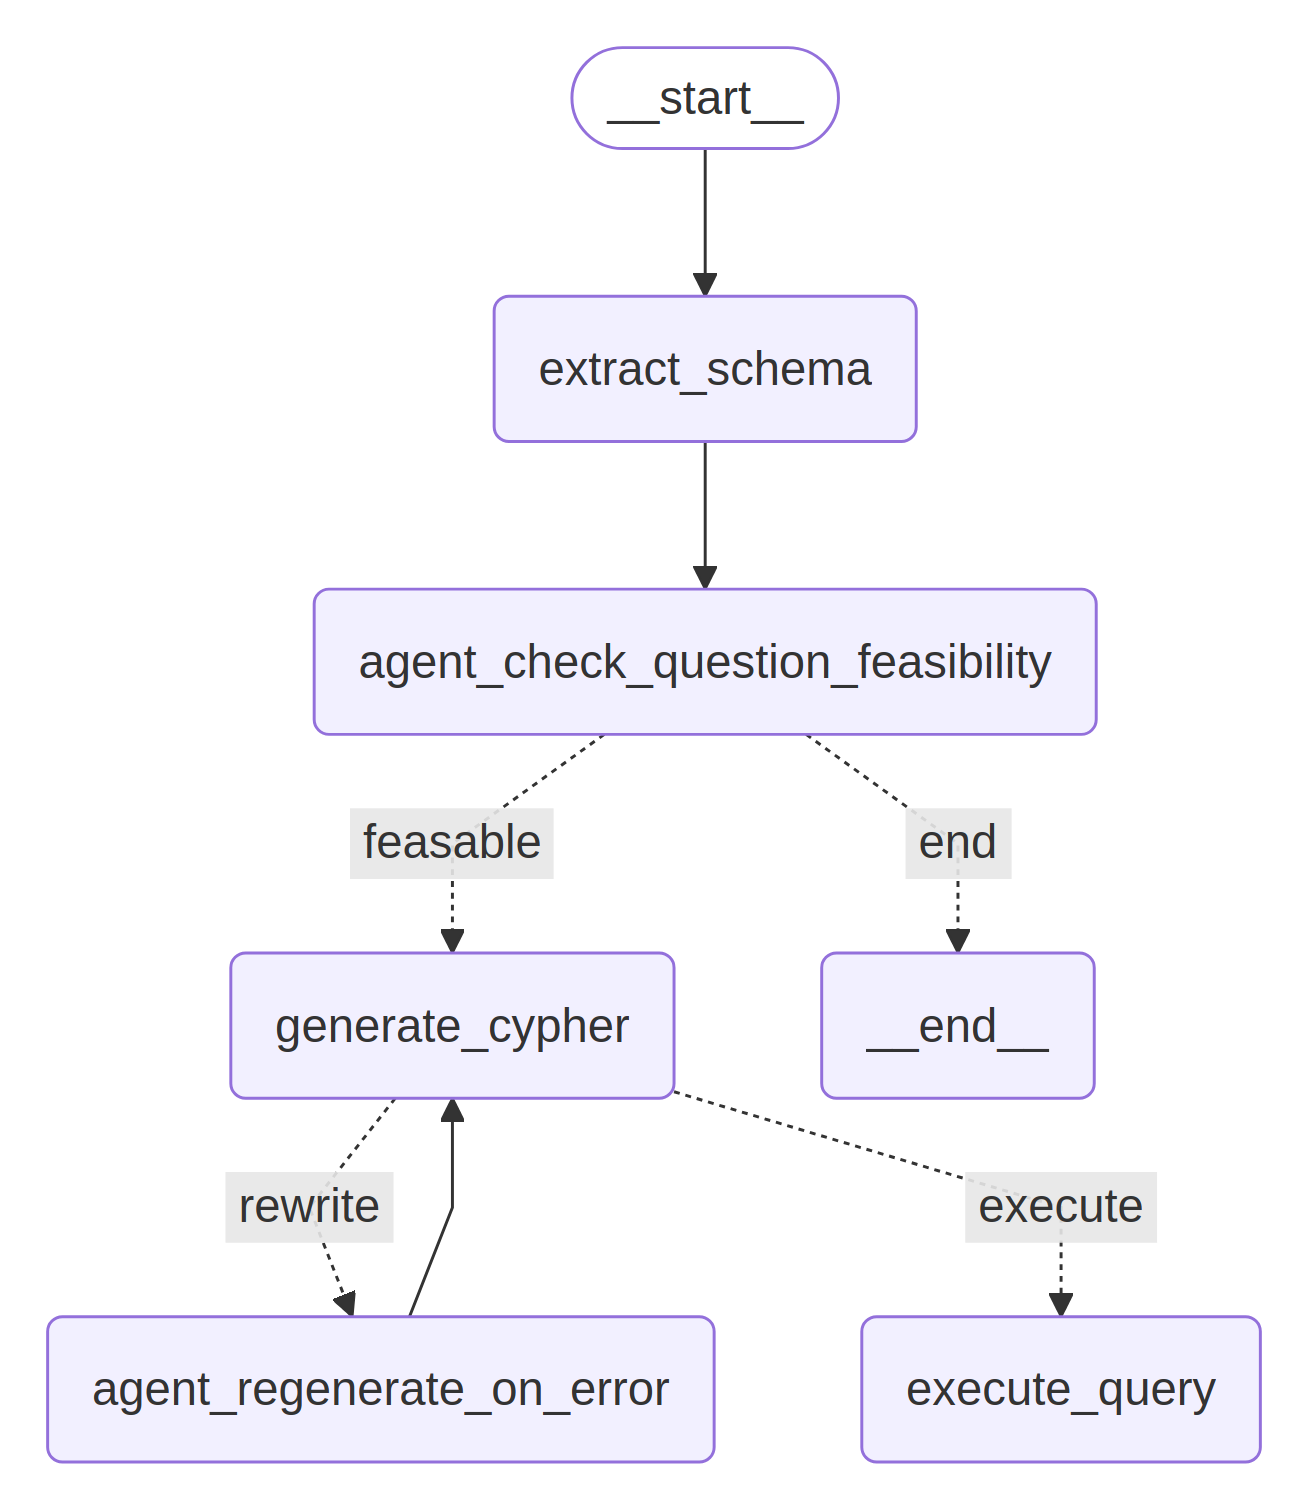

In [271]:
import asyncio
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_core.runnables.graph_mermaid import _render_mermaid_using_pyppeteer
from IPython.display import display, Image

async def display_graph_png():
    mermaid_syntax = app.get_graph().draw_mermaid()
    img_bytes = await _render_mermaid_using_pyppeteer(
        mermaid_syntax=mermaid_syntax,
        output_file_path=None,
        background_color="white",
        padding=10
    )
    display(Image(data=img_bytes))

await display_graph_png()



In [320]:
from pprint import pprint

# Run

inputs = {"question": "Combien d'actions ont été réalisées pour chaque projet ?"}
for output in app.stream(inputs):
    for node_name, node_output in output.items():
        print(f"\n🔹 Node '{node_name}':")
        print(output.items())
        print("📦 State :")
        pprint(node_output, indent=2, width=100)

        
        # Facultatif : affichage de la génération LLM si elle existe
        if "generation" in node_output:
            print("\n🧠 Generation :")
            pprint(node_output["generation"])

    print("\n" + "-" * 60 + "\n")


--EXTRACT-SCHEMA-NODE--

🔹 Node 'extract_schema':
dict_items([('extract_schema', {'question': "Combien d'actions ont été réalisées pour chaque projet ?", 'schema': 'Nodes:\n- Person(name)\n- Project(name)\n- Meeting(date)\n- Action(description)\n\nRelationships:\n- (Person)-[:ATTENDED]->(Meeting)\n- (Meeting)-[:HAS_ACTION]->(Action)\n- (Action)-[:CONCERNS]->(Project)\n\nEntity Examples:\n- Person.name = "Alice Dupont"\n- Person.name = "Bob Martin"\n- Project.name = "Projet Apollo"\n- Project.name = "Projet Borealis"\n- Meeting.date = "2025-01-15"\n- Meeting.date = "2025-02-20"\n- Action.description = "Lancer l\'étude de faisabilité du projet Apollo"\n- Action.description = "Finaliser la maquette du projet Borealis"\n'})])
📦 State :
{ 'question': "Combien d'actions ont été réalisées pour chaque projet ?",
  'schema': 'Nodes:\n'
            '- Person(name)\n'
            '- Project(name)\n'
            '- Meeting(date)\n'
            '- Action(description)\n'
            '\n'
           

In [323]:
from pprint import pprint

# Run

inputs = {"question": "Quelles sont les actions associées à chaque projet ?"}
for output in app.stream(inputs):
    for node_name, node_output in output.items():
        print(f"\n🔹 Node '{node_name}':")
        print(output.items())
        print("📦 State :")
        pprint(node_output, indent=2, width=100)

        
        # Facultatif : affichage de la génération LLM si elle existe
        if "generation" in node_output:
            print("\n🧠 Generation :")
            pprint(node_output["generation"])

    print("\n" + "-" * 60 + "\n")


--EXTRACT-SCHEMA-NODE--

🔹 Node 'extract_schema':
dict_items([('extract_schema', {'question': 'Quelles sont les actions associées à chaque projet ?', 'schema': 'Nodes:\n- Person(name)\n- Project(name)\n- Meeting(date)\n- Action(description)\n\nRelationships:\n- (Person)-[:ATTENDED]->(Meeting)\n- (Meeting)-[:HAS_ACTION]->(Action)\n- (Action)-[:CONCERNS]->(Project)\n\nEntity Examples:\n- Person.name = "Alice Dupont"\n- Person.name = "Bob Martin"\n- Project.name = "Projet Apollo"\n- Project.name = "Projet Borealis"\n- Meeting.date = "2025-01-15"\n- Meeting.date = "2025-02-20"\n- Action.description = "Lancer l\'étude de faisabilité du projet Apollo"\n- Action.description = "Finaliser la maquette du projet Borealis"\n'})])
📦 State :
{ 'question': 'Quelles sont les actions associées à chaque projet ?',
  'schema': 'Nodes:\n'
            '- Person(name)\n'
            '- Project(name)\n'
            '- Meeting(date)\n'
            '- Action(description)\n'
            '\n'
            'Relati